<p align="left">
<img src="https://raw.githubusercontent.com/dewdotninja/exams/main/feng_heading_en.png" width=400 alt="Feng heading"/>
</p>

#### Department of Mechanical Engineering

### Homework 2
Second Semester, Academic Year 2025

<br>**01208583 Robotics**

พิมพ์ชื่อ - นามสกุล และรหัสนิสิตในเซลล์ด้านล่างนี้ (สำคัญ หากเว้นว่างไว้หัก 1 คะแนน)


In [ ]:
# ชื่อ นามสกุล รหัสนิสิต

**คำสั่ง :** โน๊ตบุคนี้ประกอบด้วยส่วนที่เป็นเนื้อหาสำหรับอ่าน และส่วนที่ผู้เรียนต้องพิมพ์คำตอบ หรือเขียนโค้ดไพทอนเพื่อได้คะแนนตามที่ระบุ โดยจะเป็นส่วนที่อยู่ภายใต้คำว่า **Solution** โจทย์ปัญหามี 3 ข้อ คือ 

* [P1](#p1) 4 คะแนน
* [P2](#p2) 4 คะแนน
* [P3](#p3) 2 คะแนน

อ่านคำสั่งตรงส่วนที่เป็นคะแนนให้เข้าใจชัดเจนว่าโจทย์ต้องการเอาต์พุตอะไร แล้วเขียนโค้ดเพื่อให้ได้เอาต์พุตนั้น เอาต์พุตที่ถูกต้องจะต้องค้างอยู่ใน notebook นี้โดยผู้ตรวจไม่ต้องรันใหม่ 
นอกจากเป็นที่สงสัย อาจจะรันโน๊ตบุคใหม่ตั้งแต่เซลล์บนสุด 
เซลล์ใดที่มีคะแนนและมีเอาต์พุตเป็น error message จะได้คะแนนศูนย์ทันที   

***

<a id="p1"></a>

## P1 (4 คะแนน)

จากตัวอย่าง 2.7 โจทย์คือหาคำตอบของปัญหาการโปรแกรมกำลังสอง (Quadratic Program) ต่อไปจะเรียกโดยย่อว่า QP
เมื่อพิจารณาเฉพาะเงื่อนไขบังคับแบบอสมการ 
ในการบ้านนี้จะยังคงยึดกับโจทย์นี้ เพียงแต่เปลี่ยนเป็นใช้ข้อมูลฟังก์ชันมูลค่าและเงื่อนไขดังนี้
$$
\underset{x}{min} \;\; \frac{1}{2}\tilde{x}^TQ\tilde{x} 
$$
โดย
$$
Q = \left[\begin{array}{cc}
2.0 & 0 \\
0 & 0.5
\end{array}\right]
$$
$$
\tilde{x} = x + [1, 2]
$$

สำหรับเงื่อนไขบังคับ $Ax \ge b$ หรือ $c(x) = Ax-b \ge 0$ใช้ข้อมูลดังนี้
$$
A = [0.5, 1.0], \;\; b = 1.0
$$

หากต้องการใช้การคำนวณอนุพันธ์อัตโนมัติ สามารถใช้แพ็กเกจใดก็ได้ (ตัวเลือกที่ใช้ในหนังสือคือ jax, torch, drake)

### SOlution

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from numpy.linalg import norm, solve
import torch
from torch.func import jacfwd

สร้างฟังก์ชันมูลค่าตามข้อมูลดังนี้

In [2]:
Q = np.diag([2.0,0.5])
Q
# objective function
def f(x):
    x1 = np.array(x) + np.array([[1],[2]])
    return 0.5*(x1.T@Q@x1)[0,0]

# gradient 
def df(x):
    x1 = np.array(x) + np.array([[1],[2]])
    return Q@x1

# hessian 
def d2f(x):
    return Q


สำหรับเงื่อนไขบังคับ $Ax \ge b$ หรือ $c(x) = Ax-b \ge 0$ใช้ข้อมูลดังนี้

In [3]:
# constraint and gradient
A = np.array([0.5, 1.0])
#print(A.shape)
b = 1.0
             
def c(x):
    return (np.dot(A,x) - b)

def dc(x):
    return A  


เขียนฟังก์ชัน plot_landscape() คล้ายกับตัวอย่าง 2.6 เพียงแก้ไขให้สอดคล้องกับข้อมูลใหม่

In [4]:
def plot_landscape():
    Nsamp = 20
    x = np.linspace(-4,4,Nsamp)
    y = np.linspace(-4,4,Nsamp)
    X, Y = np.meshgrid(x,y)
    Z = np.zeros((Nsamp,Nsamp))
    for j in range(Nsamp):
        for k in range(Nsamp):
            Z[j,k] = f([[X[j,k]], [Y[j,k]]])
    fig, ax = plt.subplots()
    CS = ax.contour(X,Y,Z)
    ax.clabel(CS, fontsize = 10)

    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.grid(True)

    xc = np.linspace(-4,4, Nsamp)
    yc = -0.5*xc+1
    ax.plot(xc,yc,'y-')

    return ax
 

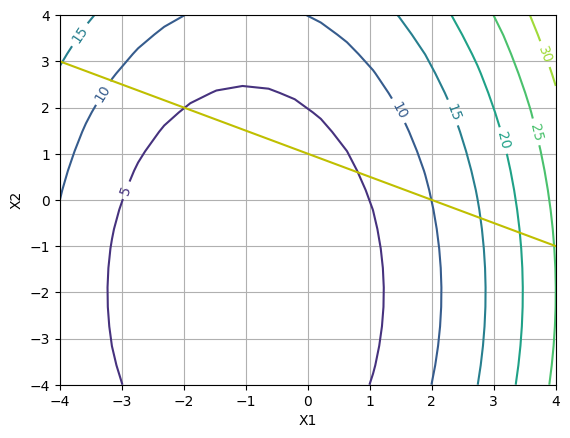

In [5]:
ax = plot_landscape() 

เขียนฟังก์ชัน newton_solve() ตามเค้าโครงอัลกอริทึม AL ในบทที่ 2

In [6]:
def newton_solve(x0, Lambda, rho):
    i = 1 # iteration count 
    x = np.expand_dims(x0,axis=1)
    cx = c(x)
    p = np.minimum(0, cx)
    C = np.zeros((1,2))
    if (cx <= 0):
        C = dc(x).reshape((1,2))
    g = df(x) + (-Lambda+rho*p)*C.T
    while norm(g) >= 1e-8:
        H = d2f(x) + rho*C.T@C  
        dx = solve(-H,g)
        x = x + dx        
        cx = c(x)
        p = np.minimum(0, cx);
        C = np.zeros((1,2));
        if (cx <= 0):
            C = dc(x).reshape((1,2))
        g = df(x) + (-Lambda+rho*p)*C.T; 
        i+=1
    return x

สร้างฟังก์ชันสำหรับแสดงค่า $x$ ที่ถูกปรับ โดยแต่ละขั้นจะแสดงการเคลื่อนที่ของ $x$ เป็นเส้นตรงกำกับโดยลูกศร

In [7]:
def plot_steps(xguess,i):
    ax = plot_landscape()
    ax.scatter(xguess[0,:], xguess[1,:],marker='x',color='g') 
    ax.scatter(xguess[0,-1], xguess[1,-1],marker='x',color='r')
    for ix in range(xguess.shape[1]-1):
        x1_old = xguess[0,ix]
        x1_new = xguess[0,ix+1]
        x2_old = xguess[1,ix]
        x2_new = xguess[1,ix+1]
        # print("x1_old = {}, x1_new = {}, x2_old = {}, x2_new = {}".format(x1_old,x1_new,x2_old,x2_new))
        if np.linalg.norm(xguess[:,ix] - xguess[:,ix+1]).item() > 0.1: # plot arrow if distance large enough
            ax.arrow(x1_old,x2_old,(x1_new-x1_old)/2,(x2_new-x2_old)/2,head_width=0.1,color='m')
    ax.plot(xguess[0,:], xguess[1,:],'m')    
    ax.set_title('Iteration : '+str(i))

เริ่มต้นทดสอบโดยเลือกค่าเริ่มต้นที่อยู๋ในย่านที่เป็นไปได้ เช่น $x_0 = [3.0, 2.0]$

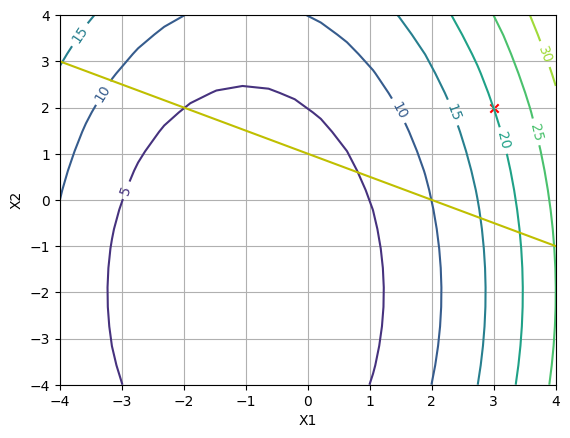

In [16]:
xguess = np.array([[3.0],[2.0]])
lambdaguess = [0.0]
rho = 1.0
i = 0 
ax = plot_landscape()
ax.scatter(xguess[0], xguess[1],marker='x',color='r')

รันเซลล์ด้านล่างแพื่อแสดงแต่ละขั้นของอัลกอริทึมในการลู่เข้าสู่คำตอบ

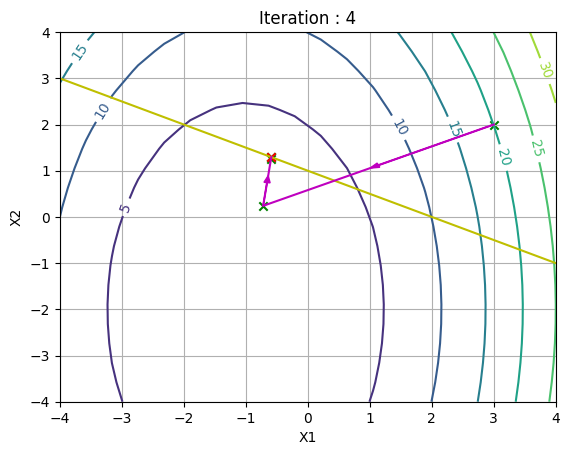

In [20]:
xnew = newton_solve(xguess[:,-1],lambdaguess[-1],rho);
lambdanew = np.maximum(0, lambdaguess[-1]-rho*c(xnew))
xguess = np.hstack((xguess, xnew))
lambdaguess.append(lambdanew)
rho = 10*rho
i+=1
plot_steps(xguess,i)

In [21]:
xnew

array([[-0.58823531],
       [ 1.29411754]])

จะเห็นว่าเมื่อวนซ้ำ 4 ครั้ง อัลกอริทึม AL ลู่เข้าสู่คำตอบ $x = [-0.5882, 1.2941]$ 

ตรวจสอบค่า $\lambda$ ที่ประมาณได้ และค่า $\rho$

In [22]:
lambdanew,rho

(array([1.64705877]), 10000.0)

ทดลองเลือกค่าเริ่มต้นที่อยู๋ในย่านที่เป็นไปไม่ได้ เช่น $x_0 = [-3.0, -1.0]$

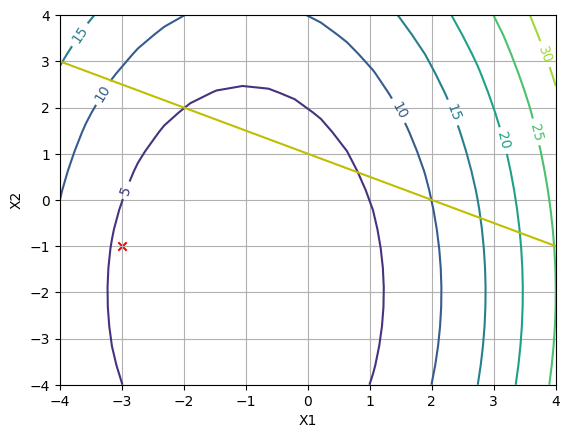

In [23]:
xguess = np.array([[-3.0],[-1.0]])
lambdaguess = [0.0]
rho = 1.0
i = 0 
ax = plot_landscape()
ax.scatter(xguess[0], xguess[1],marker='x',color='r')

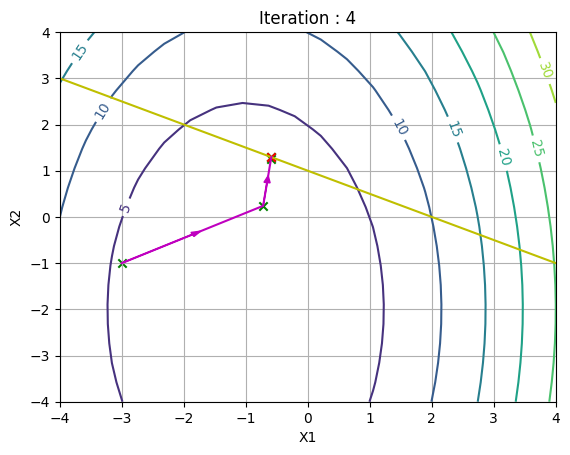

In [27]:
xnew = newton_solve(xguess[:,-1],lambdaguess[-1],rho);
lambdanew = np.maximum(0, lambdaguess[-1]-rho*c(xnew))
xguess = np.hstack((xguess, xnew))
lambdaguess.append(lambdanew)
rho = 10*rho
i+=1
plot_steps(xguess,i)

จะเห็นว่าคำตอบลู่เข้าสู่จุดที่ประมาณเท่ากับครั้งก่อนหน้า $x = [-0.5882, 1.294]$   

In [28]:
xnew

array([[-0.58823531],
       [ 1.29411754]])

In [29]:
lambdanew, rho

(array([1.64705877]), 10000.0)

***

<a id="p2"></a>

## P2 (4 คะแนน)

จากข้อมูลฟังก์ชันมูลค่าและเงื่อนไขเดียวกันกับโจทย์ข้อ P1 คือ

$$
\underset{x}{min} \;\; \frac{1}{2}\tilde{x}^TQ\tilde{x} 
$$
โดย
$$
Q = \left[\begin{array}{cc}
2.0 & 0 \\
0 & 0.5
\end{array}\right]
$$
$$
\tilde{x} = x + [1, 2]
$$

สำหรับเงื่อนไขบังคับ $Ax \ge b$ หรือ $c(x) = Ax-b \ge 0$ใช้ข้อมูลดังนี้
$$
A = [0.5, 1.0], \;\; b = 1.0
$$

ใช้วิธีจุดภายใน (IP) เพื่อหาคำตอบ ตรวจสอบว่าได้คำตอบเดียวกันกับโจทย์ข้อ P1 หรือไม่?

**hint :** ใช้โค้ดจากตัวอย่าง 2.8 สำหรับวิธีการ IP 

### Solution

นำเข้าแพ็กเกจที่ใช้งาน โดยจะใช้ torch ช่วยในการหาอนุพันธ์อัตโนมัติ 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import torch
from torch.linalg import norm, solve 
from torch.func import jacfwd

สร้างฟังก์ชันมูลค่า เงื่อนไขบังคับ ฟังก์ชัน landscape() ดังเช่นโจทย์ข้อ P1 เพียงแต่ใช้ฟังก์ชันของ torch แทน numpy เพื่อรองรับการทำ AD 


In [14]:
Q = torch.diag(torch.tensor([2.0,0.5]))

# objective function
def f(x):
    x1 = x + torch.tensor([[1],[2]])
    return 0.5*(x1.T@Q@x1)[0,0]

# gradient 
def df(x):
    x1 = x + torch.tensor([[1],[2]])
    return Q@x1

# hessian 
def d2f(x):
    return Q


In [3]:
# constraint and gradient
A = torch.tensor([0.5, 1.0]).reshape(2,1)
b = torch.tensor(1.0)
             
def c(x):
    return (A.T@x - b)

def dc(x):
    return A  


In [5]:
def plot_landscape():
    # plot level curve of f(x)
    Nsamp = 20
    x = np.linspace(-4,4,Nsamp)
    y = np.linspace(-4,4,Nsamp)
    X, Y = np.meshgrid(x,y)
    X = X.astype(np.float32)
    Y = Y.astype(np.float32)
    Z = np.zeros((Nsamp,Nsamp))
    for j in range(Nsamp):
        for k in range(Nsamp):
            Z[j,k] = f(torch.tensor([[X[j,k]], [Y[j,k]]]))
    fig, ax = plt.subplots()
    CS = ax.contour(X,Y,Z)
    ax.clabel(CS, fontsize = 10)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')

    # plot constraint c(x)
    xc = np.linspace(-4.0,4.0, Nsamp)
    yc = -0.5*xc+1
    ax.plot(xc,yc,'orange')

    return ax


พล็อตเส้นโค้งระดับของฟังก์ชันมูลค่าและเงื่อนไขบังคับเส้นตรง 

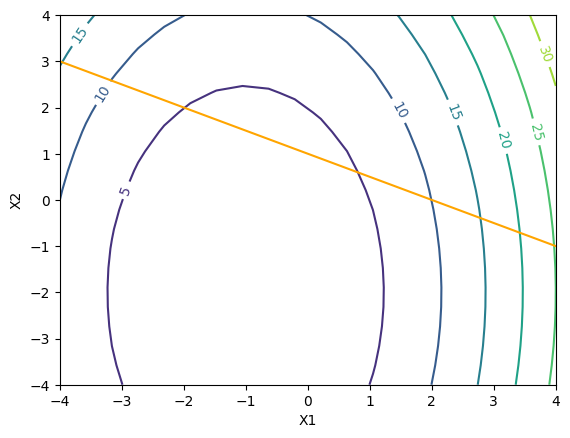

In [6]:
ax = plot_landscape()

เขียนฟังก์ชัน ip_residual() เพื่อตรวจสอบ (2.46), (2.47) ว่ามีค่าแตกต่างจากศูนย์เท่าใด 

In [7]:
def ip_residual(z, rho):
    x = z[0:2]
    sigma = z[2]
    ru = df(x) - dc(x).T.reshape(2,1)*torch.sqrt(rho)*torch.exp(-sigma)
    rl = c(x) - torch.sqrt(rho)*torch.exp(sigma)
    r = torch.vstack([ru,rl])
    return r

สร้างฟังก์ชันเสริม kkt_residual() สำหรับตรวจสอบเงื่อนไข KKT 

In [8]:
def kkt_residual(z):
    x = z[0:2]
    sigma = z[2]
    Lambda = torch.sqrt(rho)*torch.exp(-sigma)

    ru = df(x) - dc(x).T.reshape(2,1)*Lambda
    t_zero = torch.zeros(1)
    r = torch.vstack([ru,torch.minimum(Lambda,t_zero),torch.minimum(c(x),t_zero),Lambda*c(x)])
    return r

เขียนฟังก์ชัน ip_newton_solve() เพื่อหาคำตอบโดยวิธี IP ได้ดังนี้

In [9]:
def ip_newton_solve(z0,rho,tol):
    global M,r,dz

    # rho_global = rho
    # initial guess
    z = z0

    # KKT residual
    r = ip_residual(z,rho)

    while norm(r) > tol:
        # Newton step
        M = torch.squeeze(jacfwd(ip_residual,argnums=0)(z,rho))
        # M = jnp.asarray(jax.jacfwd(ip_residual_wrapper)(z)).reshape(3,3)
        dz = solve(-M,r)
        znew = z + dz
        rnew = ip_residual(znew,rho)
        # inexpensive line search
        b = 0.1
        d = 0.5
        alpha = 1.0
        norm_r = norm(r)
        while norm(rnew) > (norm_r + b*alpha*r.T@M@dz/norm_r):
            alpha = d*alpha
            znew = z + alpha*dz
            rnew = ip_residual(znew,rho)

        z = znew
        r = rnew

    return z

ใช้ฟังก์ชัน plot_steps() เหมือนกับโจทย์ข้อ P1

In [10]:
def plot_steps(xguess,i):
    ax = plot_landscape()
    ax.scatter(xguess[0,:], xguess[1,:],marker='x',color='g') 
    ax.scatter(xguess[0,-1], xguess[1,-1],marker='x',color='r')
    for ix in range(xguess.shape[1]-1):
        x1_old = xguess[0,ix]
        x1_new = xguess[0,ix+1]
        x2_old = xguess[1,ix]
        x2_new = xguess[1,ix+1]
        if np.linalg.norm(xguess[:,ix] - xguess[:,ix+1]).item() > 0.1: # plot arrow if distance large enough
            ax.arrow(x1_old,x2_old,(x1_new-x1_old)/2,(x2_new-x2_old)/2,head_width=0.1,color='m')
    ax.plot(xguess[0,:], xguess[1,:],'m') 
    ax.set_title('Iteration : '+str(i))

กำหนดตำแหน่ง $x_0 = [3.0, 3.0]$ ในย่านที่เป็นไปได้ และตั้งค่าเริ่มต้น พล็อตโดย plot_landscape()

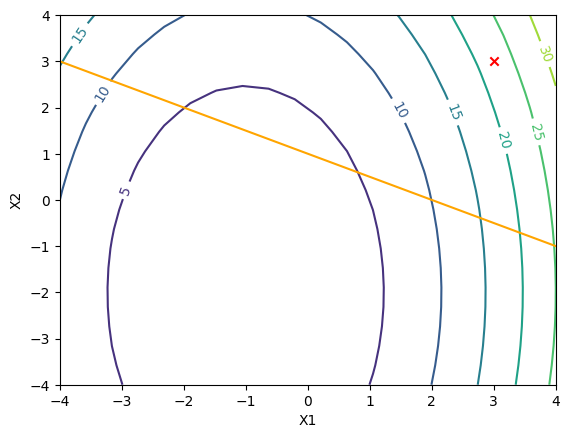

In [17]:
i=0
rho_hist=[]
xguess = torch.tensor([[3.0],[3.0]],requires_grad=True)
sigmaguess = torch.tensor([0.0], requires_grad=True)
z = torch.vstack([xguess, sigmaguess])
ax = plot_landscape()
xguess_np = xguess.detach().numpy()
ax.scatter(xguess_np[0], xguess_np[1],marker='x',color='r')
z_iter = z
plt.show()

รันเซลล์ด้านล่างนี้ซ้ำ โดยลดค่าตัวแปร rho จากค่าเริ่มต้น 1.0 น้อยลงจนถึงค่าที่ต้องการ เช่น 1e-8 (หรืออาจใช้ค่าน้อยในทันทีได้เลยเนื่องจากปัญหาเป็นคอนเว็กซ์)
ใช้ฟังก์ชัน plot_steps() เพื่อดูการลู่เข้าสู่คำตอบของค่า $x$

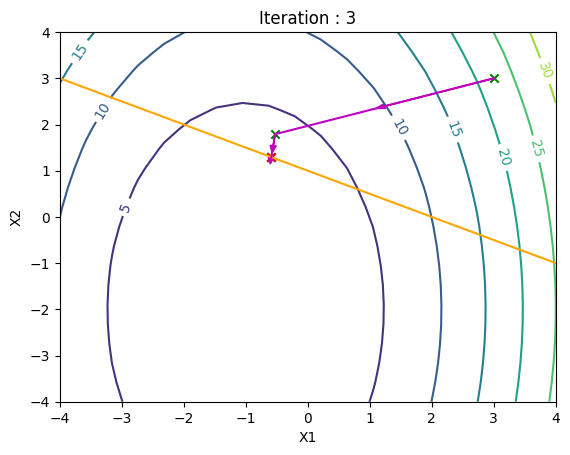

In [20]:
rho = torch.tensor(1e-8) # reduce from 1.0 down to very small, say, 1e-8
z = ip_newton_solve(z_iter[:,-1].reshape(3,1), rho, 1e-6)
z_iter = torch.hstack([z_iter,z])
rho_hist.append(rho.detach().numpy())
i+=1 
plot_steps(z_iter.detach().numpy(),i)

ค่าของ rho ที่ใช้จะถูกเก็บในลิสต์ rho_hist

In [21]:
for i in range(len(rho_hist)):
    print("iteration {} : rho = {}".format(i,rho_hist[i]))

iteration 0 : rho = 1.0
iteration 1 : rho = 0.0010000000474974513
iteration 2 : rho = 9.99999993922529e-09


เปรียบเทียบค่าคำตอบที่ได้จากวิธี IP กับวิธี AL ในโจทย์ข้อ P1 จะเห็นว่าได้ประมาณเท่ากัน

In [22]:
z[0:2].detach().numpy()

array([[-0.58823526],
       [ 1.2941177 ]], dtype=float32)

เอาต์พุตจากฟังก์ชัน ip_residual() และ kkt_residual() จะต้องใกล้เคียงศูนย์ที่จุดคำตอบ

In [23]:
ip_residual(z,rho).detach().numpy()

array([[ 5.9604645e-08],
       [ 0.0000000e+00],
       [-6.0714291e-09]], dtype=float32)

In [24]:
kkt_residual(z).detach().numpy()

array([[5.9604645e-08],
       [0.0000000e+00],
       [0.0000000e+00],
       [0.0000000e+00],
       [0.0000000e+00]], dtype=float32)

**Optional :** เราจะลองทดสอบว่าหากเลือกจุดเริ่มต้นนอกย่านที่เป็นไปได้จะเกิดผลอย่างไร เช่นเลือก $x_0 = [-3.0, -1.0]$

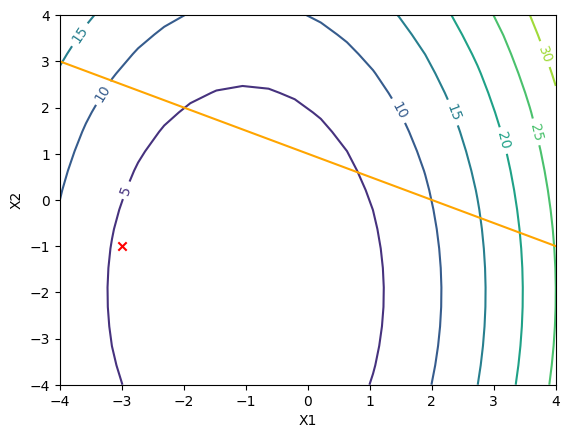

In [30]:
i=0
rho_hist=[]
xguess = torch.tensor([[-3.0],[-1.0]],requires_grad=True)
sigmaguess = torch.tensor([0.0], requires_grad=True)
z = torch.vstack([xguess, sigmaguess])
ax = plot_landscape()
xguess_np = xguess.detach().numpy()
ax.scatter(xguess_np[0], xguess_np[1],marker='x',color='r')
z_iter = z
plt.show()

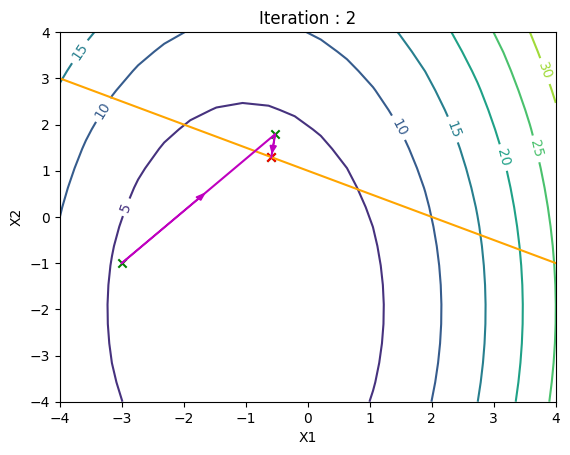

In [32]:
rho = torch.tensor(0.001) # reduce from 1.0 down to very small, say, 1e-8
z = ip_newton_solve(z_iter[:,-1].reshape(3,1), rho, 1e-6)
z_iter = torch.hstack([z_iter,z])
rho_hist.append(rho.detach().numpy())
i+=1 
plot_steps(z_iter.detach().numpy(),i)

เราพบว่าอัลกอริทึมสามารถทำงานได้ โดยในขั้นแรกค่าของ $x$ ถูกปรับเข้าสู่ย่านที่เป็นไปได้ (หรือหากใช้ค่า rho น้อยตั้งแต่แรก จะลู่เข้าสู่คำตอบในทันที) 

ในอดีตวิธีการ IP จะมีปัญหาหากเลือกจุดเริ่มต้นนอกเขตที่เป็นไปได้ ต้องใช้วิธีการเช่นการค้นหาตามเส้นในการตรวจสอบ ซึ่งยุ่งยากและเสียเวลา วิธีการ log-domain ที่ใช้ในตัวอย่าง 2.8 สามารถช่วยแก้ไขปัญหานี้ทำให้อัลกอริทึมทำงานได้แม้เลือกจุดเริ่มต้นภายนอกเขตที่เป็นไปได้ (แม้ในอัลกอริทึมจะยังมีการค้นหาตามเส้น แต่เป็นอย่างง่ายที่ไม่ต้องการการคำนวณมาก)

***

<a id="p3"></a>

## P3 (2 คะแนน)

ใช้ตัวหาคำตอบ (solver) เช่น IPOPT,cvx, drake,osqp etc. (เลือกเพียงตัวเดียว) หาคำตอบของโจทย์เดียวกันนี้ คือ 

$$
\underset{x}{min} \;\; \frac{1}{2}\tilde{x}^TQ\tilde{x} 
$$
โดย
$$
Q = \left[\begin{array}{cc}
2.0 & 0 \\
0 & 0.5
\end{array}\right]
$$
$$
\tilde{x} = x + [1, 2]
$$

สำหรับเงื่อนไขบังคับ $Ax \ge b$ หรือ $c(x) = Ax-b \ge 0$ใช้ข้อมูลดังนี้
$$
A = [0.5, 1.0], \;\; b = 1.0
$$

### Solution

เนื่องจากปัญหานี้มีรูปแบบของ QP ดังนั้นจึงเหมาะสมในการเลือกใช้ OSQP รายละเอียดศึกษาได้จาก https://osqp.org/

นำเข้าแพ็กเกจที่ต้องการใช้

In [28]:
import numpy as np
from scipy.sparse import csc_array
import osqp

ในการตั้งค่าสำหรับ OSQP ไม่ต้องการนิยามฟังก์ชัน เพียงต้องการข้อมูลในรูปเมทริกซ์และขอบเขตเท่านั้น ดังนั้นเราจัดรูปโค้ดจากโจทย์ให้เหมาะสม โดย OSQP กำหนดให้เมทริกซ์​ Q (OSQP เรียกว่า P) และเมทริกซ์ A ต้องเป็นแบบ sparse 


In [29]:
Q = np.diag([2.0,0.5])
Q_sparse = csc_array(Q)  # OSQP requirement
# original objective function
# def f(x):
#     x1 = np.array(x) + np.array([[1],[2]])
#     return 0.5*(x1.T@Q@x1)[0,0]

# rewrite to the form 0.4x.T@Q@x + q.T@x only to cast to OSQP format
# to get matrix q. The actual function is not needed in the setup

x_bar = np.array([[1],[2]])
q = x_bar.T@Q
def f(x):
    return (0.5*(x.T@Q@x)+q@x)[0]



# gradient
# These functions are also not needed for OSQP problem setup.

# original df() function
# def df(x):
#     x1 = np.array(x) + np.array([[1],[2]])
#     return Q@x1

def df(x):
    return Q@x + q.T

# hessian 
def d2f(x):
    return Q

# constraint and gradient
A = np.array([0.5, 1.0]).reshape(1,2)
A_sparse = csc_array(A) # OSQP requirement
b = 1.0

# These functions are not required in the OSQP problem setup   
def c(x):
    return (np.dot(A,x) - b)

def dc(x):
    return A  

def d2c(x):
    return np.zeros((2,2))

สร้างวัตถุ OSQP ขึ้นมาก่อน

In [30]:
# Create an OSQP object
prob = osqp.OSQP()


กำหนดขอบเขตด้านล่าง l และด้านบน u

In [31]:
l = np.array([b])
u = np.array([10000.0])

ตั้งค่าให้กับ prob 

In [32]:
prob.setup(P=Q_sparse,q=q.T,A=A_sparse,l=l,u=u,alpha=1.0)

-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 2, constraints m = 1
          nnz(P) + nnz(A) = 4
settings: algebra = Built-in,
          OSQPInt = 8 bytes, OSQPFloat = 8 bytes,
          linear system solver = QDLDL v0.1.8,
          eps_abs = 1.0e-03, eps_rel = 1.0e-03,
          eps_prim_inf = 1.0e-04, eps_dual_inf = 1.0e-04,
          rho = 1.00e-01 (adaptive: 50 iterations),
          sigma = 1.00e-06, alpha = 1.00, max_iter = 4000
          check_termination: on (interval 25, duality gap: on),
          time_limit: 1.00e+10 sec,
          scaling: on (10 iterations), scaled_termination: off
          warm starting: on, polishing: off, 


/opt/anaconda3/envs/ocrl/lib/python3.13/site-packages/osqp/interface.py:226: UserWarning: Converting sparse P to a CSC matrix. This may take a while...
  warnings.warn('Converting sparse P to a CSC matrix. This may take a while...')
/opt/anaconda3/envs/ocrl/lib/python3.13/site-packages/osqp/interface.py:229: UserWarning: Converting sparse A to a CSC matrix. This may take a while...
  warnings.warn('Converting sparse A to a CSC matrix. This may take a while...')


หาคำตอบ

In [33]:
res = prob.solve()

iter   objective    prim res   dual res   gap        rel kkt    rho         time
   1  -1.8693e+00   2.75e+00   2.00e-01  -1.17e+00   2.75e+00   1.00e-01    2.67e-05s
  25   8.8157e-01   4.76e-04   3.81e-10  -7.84e-04   4.76e-04   1.00e-01    3.45e-05s

status:               solved
number of iterations: 25
optimal objective:    0.8816
dual objective:       0.8824
duality gap:          -7.8443e-04
primal-dual integral: 1.1668e+00
run time:             3.98e-05s
optimal rho estimate: 1.58e+02



ตรวจสอบคำตอบจะพบว่าได้ค่าประมาณเท่ากันกับคำตอบจากโจทย์ข้อ P1 และ P2

In [34]:
res.x

array([-0.58829133,  1.29366934])


<div align="right">Rev 1A : 31 มกราคม 2569</div>

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>